# Image Inpainting with GANs on CIFAR-10

This notebook demonstrates an implementation of a Generative Adversarial Network (GAN) designed from the ground up to tackle an image inpainting task. Specifically, we work with the CIFAR-10 dataset, a collection of small color images across 10 different categories. To simulate missing or occluded regions, each image is deliberately masked by placing a black square at the center. The goal of our GAN is to reconstruct these masked regions as realistically as possible based on the surrounding image context.

Our approach does not rely on any pretrained models or libraries specific to GANs; instead, we manually define and train both the generator and discriminator architectures. To assess the performance of the inpainting results, we incorporate two perceptual similarity metrics: **Peak Signal-to-Noise Ratio (PSNR)** and **Structural Similarity Index Measure (SSIM)**. These help quantify the fidelity and structural coherence of the generated image patches compared to the original unmasked versions.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from skimage.metrics import structural_similarity as ssim
from math import log10
from tqdm import tqdm

### GAN Architecture (UNet based)

In [2]:
class GeneratorUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super(GeneratorUNet, self).__init__()

        self.enc1 = self.contract_block(in_channels, 64, normalize=False)
        self.enc2 = self.contract_block(64, 128)
        self.enc3 = self.contract_block(128, 256)

        self.bottleneck = self.contract_block(256, 512, normalize=False)

        self.dec3 = self.expand_block(512, 256)
        self.dec2 = self.expand_block(512, 128)
        self.dec1 = self.expand_block(256, 64)

        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, out_channels, 4, 2, 1),
            nn.Tanh()
        )

    def contract_block(self, in_channels, out_channels, normalize=True):
        layers = [nn.Conv2d(in_channels, out_channels, 4, 2, 1, bias=False)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.LeakyReLU(0.2))
        return nn.Sequential(*layers)

    def expand_block(self, in_channels, out_channels):
        layers = [
            nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(True)
        ]
        return nn.Sequential(*layers)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)

        b = self.bottleneck(e3)

        d3 = self.dec3(b)
        d3 = torch.cat((d3, e3), 1)
        d2 = self.dec2(d3)
        d2 = torch.cat((d2, e2), 1)
        d1 = self.dec1(d2)
        d1 = torch.cat((d1, e1), 1)
        out = self.final(d1)
        return out



### Patch Based Discriminator

In [3]:
class PatchDiscriminator(nn.Module):
    def __init__(self, input_nc=3):
        super().__init__()
        self.model = nn.Sequential(
            self.block(input_nc, 64, normalize=False),
            self.block(64, 128),
            self.block(128, 256),
            nn.Conv2d(256, 1, kernel_size=4, stride=1, padding=0),
            nn.Sigmoid()
        )

    def block(self, in_channels, out_channels, normalize=True):
        layers = [nn.Conv2d(in_channels, out_channels, 4, 2, 1)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        return nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

### Saving checkpoints
we need to implement functions to save the states at each epoch to avoid progression loss while training.

In [4]:

def store_model(generator, discriminator, g_optim, d_optim, epoch_num, file_path="checkpoint.pth"):
    torch.save({
        'epoch': epoch_num,
        'gen_state': generator.state_dict(),
        'disc_state': discriminator.state_dict(),
        'gen_optim': g_optim.state_dict(),
        'disc_optim': d_optim.state_dict()
    }, file_path)
    print(f"=> Saved checkpoint at epoch {epoch_num}")


def restore_model(generator, discriminator, g_optim, d_optim, file_path="checkpoint.pth"):
    state = torch.load(file_path)
    generator.load_state_dict(state['gen_state'])
    discriminator.load_state_dict(state['disc_state'])
    g_optim.load_state_dict(state['gen_optim'])
    d_optim.load_state_dict(state['disc_optim'])
    print(f"=> Restored from checkpoint at epoch {state['epoch']}")
    return state['epoch']

### Mask function for center masking

In [5]:
def apply_mask(images, mask_size=16):
    masked = images.clone()
    img_height, img_width = images.size(2), images.size(3)
    start_y = (img_height - mask_size) // 2
    start_x = (img_width - mask_size) // 2
    masked[:, :, start_y:start_y + mask_size, start_x:start_x + mask_size] = -1.0
    return masked

### PSNR and SSIM Metrics

In [6]:
def psnr(original, reconstructed):
    mse = torch.mean((original - reconstructed) ** 2).item()
    if mse == 0:
        return 100
    return 20 * log10(2.0 / np.sqrt(mse))

def ssim_score(original, reconstructed):
    o = (original.cpu().numpy().transpose(1, 2, 0) + 1) / 2
    r = (reconstructed.cpu().numpy().transpose(1, 2, 0) + 1) / 2
    return ssim(o, r, channel_axis=2, data_range=1)


In [7]:
def evaluate_inpainting(generator_model, data_loader, mask_size, device):
    generator_model.eval()
    psnr_scores, ssim_scores = [], []

    with torch.no_grad():
        for batch_imgs, _ in data_loader:
            batch_imgs = batch_imgs.to(device)
            masked_batch = apply_mask(batch_imgs, mask_size).to(device)
            recon_batch = generator_model(masked_batch)

            for i in range(batch_imgs.size(0)):
                psnr_scores.append(psnr(batch_imgs[i], recon_batch[i]))
                ssim_scores.append(ssim_score(batch_imgs[i], recon_batch[i]))

    avg_psnr = np.mean(psnr_scores)
    avg_ssim = np.mean(ssim_scores)

    print(f"Average PSNR: {avg_psnr:.2f}")
    print(f"Average SSIM: {avg_ssim:.2f}")
    return avg_psnr, avg_ssim


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64
num_epochs = 70
learning_rate = 2e-4
mask_size = 16

In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [10]:
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

100%|██████████| 170M/170M [00:03<00:00, 49.3MB/s]


In [11]:
generator = GeneratorUNet().to(device)
discriminator = PatchDiscriminator().to(device)

adversarial_loss = nn.BCELoss()
reconstruction_loss = nn.L1Loss()

g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate, betas=(0.5, 0.999))

Epoch 1/70: 100%|██████████| 782/782 [00:34<00:00, 22.47it/s]


[Epoch 1/70]  Generator Loss: 0.1318  Discriminator Loss: 0.1420


Epoch 2/70: 100%|██████████| 782/782 [00:32<00:00, 24.37it/s]


[Epoch 2/70]  Generator Loss: 0.1020  Discriminator Loss: 0.1479


Epoch 3/70: 100%|██████████| 782/782 [00:32<00:00, 23.94it/s]


...

[Epoch 8/70]  Generator Loss: 0.0841  Discriminator Loss: 0.2499


Epoch 9/70: 100%|██████████| 782/782 [00:32<00:00, 23.80it/s]


[Epoch 9/70]  Generator Loss: 0.0820  Discriminator Loss: 0.2445


Epoch 10/70: 100%|██████████| 782/782 [00:32<00:00, 23.84it/s]


[Epoch 10/70]  Generator Loss: 0.0802  Discriminator Loss: 0.2453
=> Saved checkpoint at epoch 10


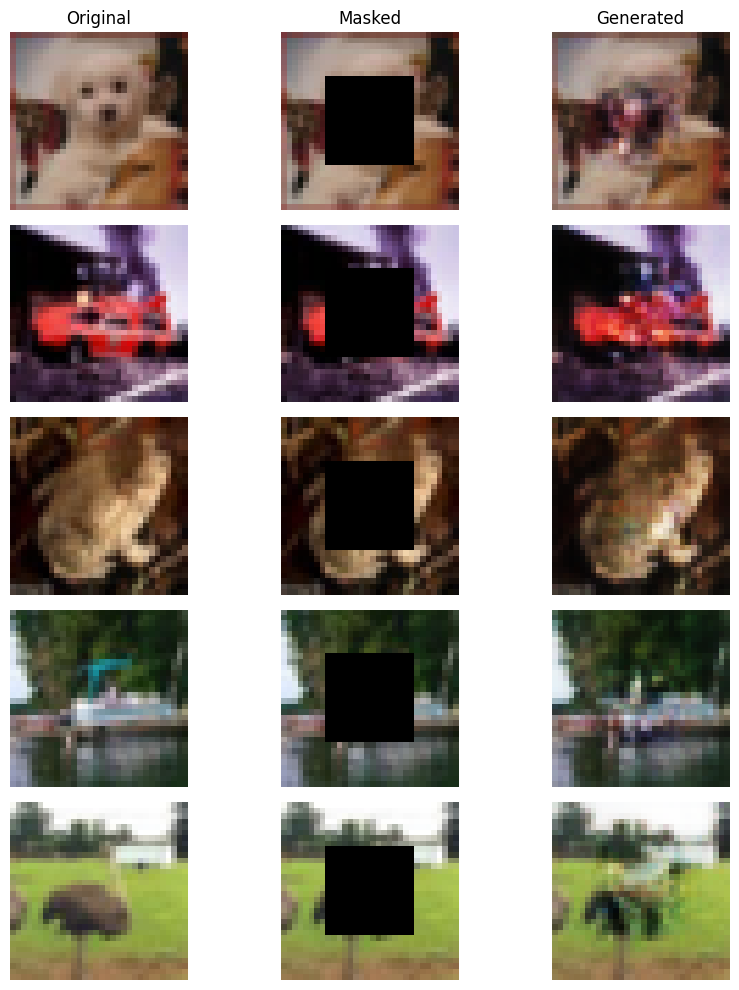

Epoch 11/70: 100%|██████████| 782/782 [00:33<00:00, 23.68it/s]


[Epoch 11/70]  Generator Loss: 0.0782  Discriminator Loss: 0.2435


Epoch 12/70: 100%|██████████| 782/782 [00:33<00:00, 23.63it/s]


[Epoch 12/70]  Generator Loss: 0.0762  Discriminator Loss: 0.2341


Epoch 13/70: 100%|██████████| 782/782 [00:33<00:00, 23.60it/s]


...

[Epoch 18/70]  Generator Loss: 0.0665  Discriminator Loss: 0.2345


Epoch 19/70: 100%|██████████| 782/782 [00:32<00:00, 24.06it/s]


[Epoch 19/70]  Generator Loss: 0.0652  Discriminator Loss: 0.2293


Epoch 20/70: 100%|██████████| 782/782 [00:32<00:00, 23.85it/s]


[Epoch 20/70]  Generator Loss: 0.0641  Discriminator Loss: 0.2295
=> Saved checkpoint at epoch 20


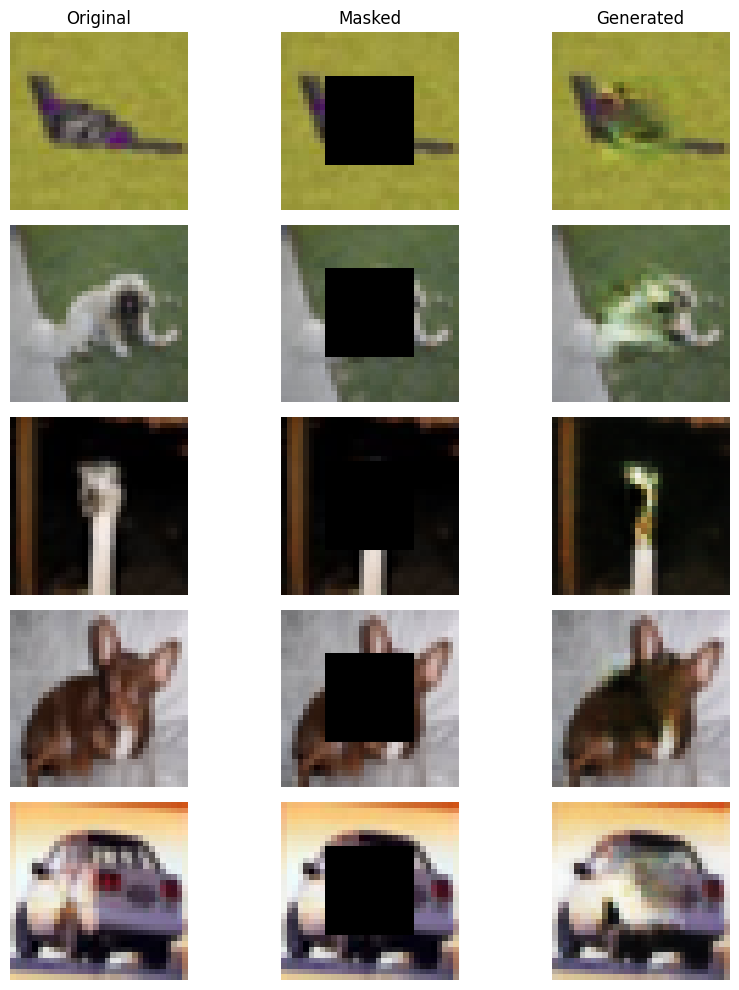

Epoch 21/70: 100%|██████████| 782/782 [00:32<00:00, 23.72it/s]


[Epoch 21/70]  Generator Loss: 0.0630  Discriminator Loss: 0.2323


Epoch 22/70: 100%|██████████| 782/782 [00:32<00:00, 23.84it/s]


[Epoch 22/70]  Generator Loss: 0.0619  Discriminator Loss: 0.2347


Epoch 23/70: 100%|██████████| 782/782 [00:32<00:00, 23.87it/s]


...

[Epoch 28/70]  Generator Loss: 0.0575  Discriminator Loss: 0.2397


Epoch 29/70: 100%|██████████| 782/782 [00:32<00:00, 23.86it/s]


[Epoch 29/70]  Generator Loss: 0.0568  Discriminator Loss: 0.2471


Epoch 30/70: 100%|██████████| 782/782 [00:32<00:00, 23.87it/s]


[Epoch 30/70]  Generator Loss: 0.0561  Discriminator Loss: 0.2411
=> Saved checkpoint at epoch 30


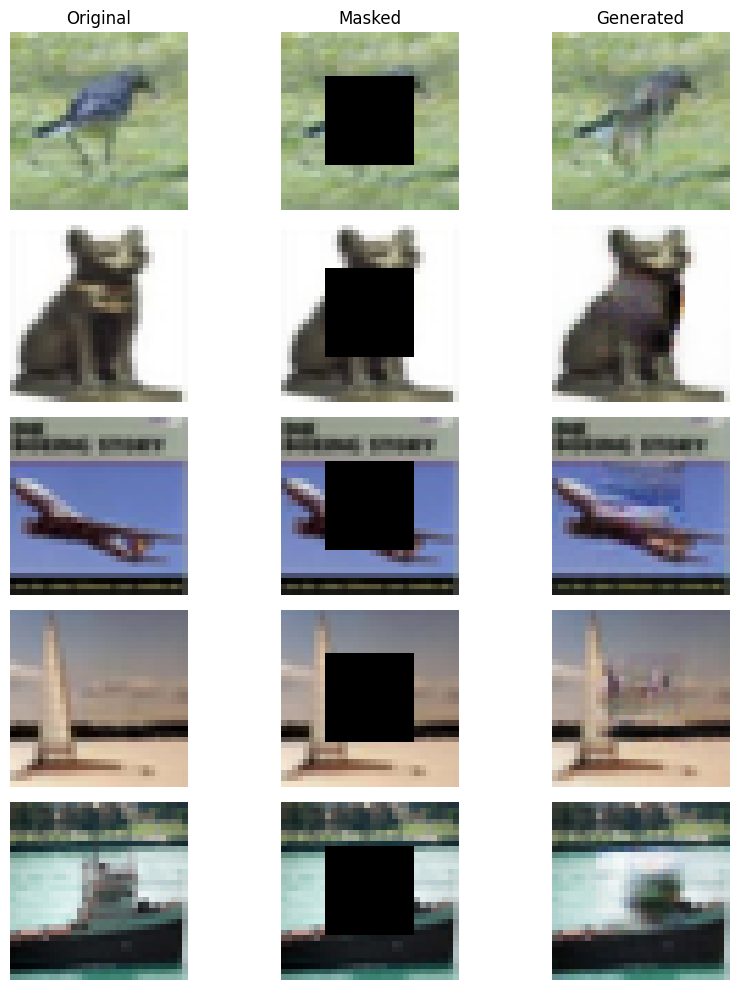

Epoch 31/70: 100%|██████████| 782/782 [00:32<00:00, 23.76it/s]


[Epoch 31/70]  Generator Loss: 0.0556  Discriminator Loss: 0.2474


Epoch 32/70: 100%|██████████| 782/782 [00:32<00:00, 23.86it/s]


[Epoch 32/70]  Generator Loss: 0.0551  Discriminator Loss: 0.2554


Epoch 33/70: 100%|██████████| 782/782 [00:32<00:00, 23.89it/s]


...

[Epoch 38/70]  Generator Loss: 0.0523  Discriminator Loss: 0.2517


Epoch 39/70: 100%|██████████| 782/782 [00:33<00:00, 23.53it/s]


[Epoch 39/70]  Generator Loss: 0.0518  Discriminator Loss: 0.2631


Epoch 40/70: 100%|██████████| 782/782 [00:33<00:00, 23.56it/s]


[Epoch 40/70]  Generator Loss: 0.0516  Discriminator Loss: 0.2579
=> Saved checkpoint at epoch 40


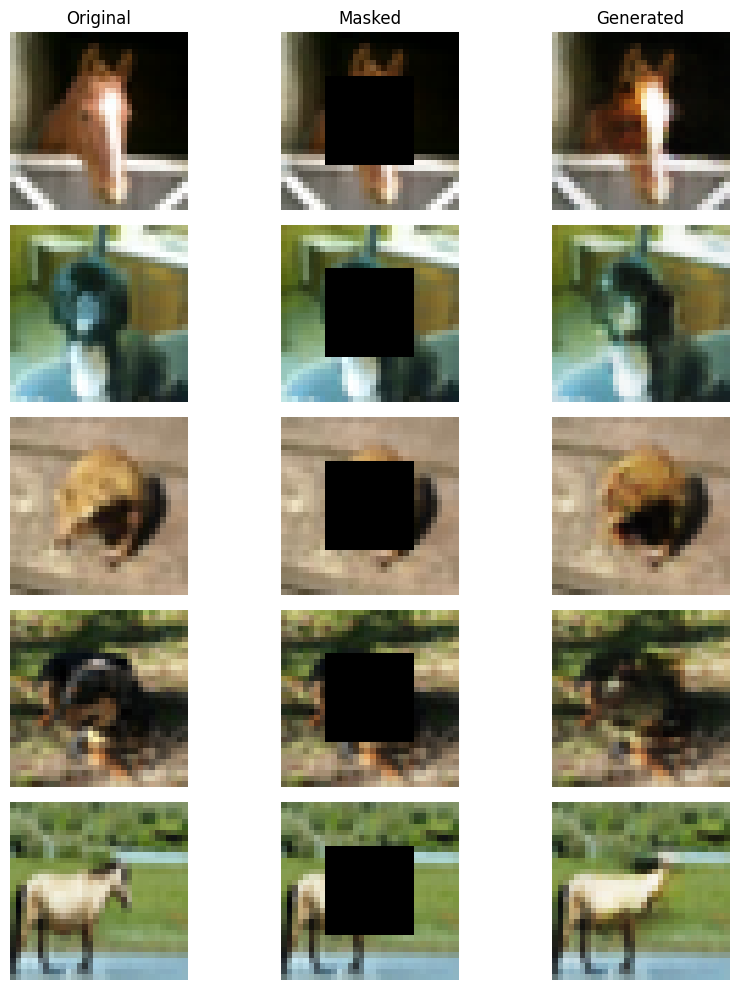

Epoch 41/70: 100%|██████████| 782/782 [00:33<00:00, 23.54it/s]


[Epoch 41/70]  Generator Loss: 0.0513  Discriminator Loss: 0.2618


Epoch 42/70: 100%|██████████| 782/782 [00:33<00:00, 23.61it/s]


[Epoch 42/70]  Generator Loss: 0.0509  Discriminator Loss: 0.2589


Epoch 43/70: 100%|██████████| 782/782 [00:32<00:00, 23.79it/s]


...

[Epoch 48/70]  Generator Loss: 0.0489  Discriminator Loss: 0.2771


Epoch 49/70: 100%|██████████| 782/782 [00:33<00:00, 23.36it/s]


[Epoch 49/70]  Generator Loss: 0.0488  Discriminator Loss: 0.2631


Epoch 50/70: 100%|██████████| 782/782 [00:32<00:00, 23.74it/s]


[Epoch 50/70]  Generator Loss: 0.0485  Discriminator Loss: 0.2603
=> Saved checkpoint at epoch 50


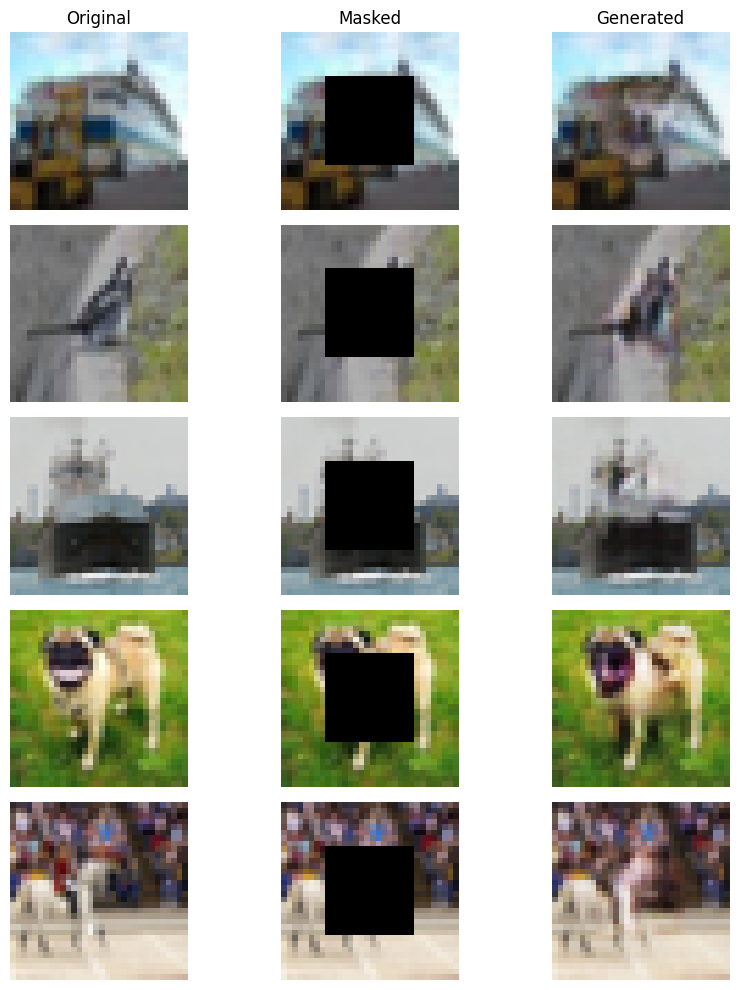

Epoch 51/70: 100%|██████████| 782/782 [00:33<00:00, 23.54it/s]


[Epoch 51/70]  Generator Loss: 0.0482  Discriminator Loss: 0.2747


Epoch 52/70: 100%|██████████| 782/782 [00:33<00:00, 23.39it/s]


[Epoch 52/70]  Generator Loss: 0.0480  Discriminator Loss: 0.2653


Epoch 53/70: 100%|██████████| 782/782 [00:33<00:00, 23.65it/s]


...

[Epoch 58/70]  Generator Loss: 0.0466  Discriminator Loss: 0.2722


Epoch 59/70: 100%|██████████| 782/782 [00:33<00:00, 23.35it/s]


[Epoch 59/70]  Generator Loss: 0.0464  Discriminator Loss: 0.2643


Epoch 60/70: 100%|██████████| 782/782 [00:32<00:00, 23.75it/s]


[Epoch 60/70]  Generator Loss: 0.0464  Discriminator Loss: 0.2679
=> Saved checkpoint at epoch 60


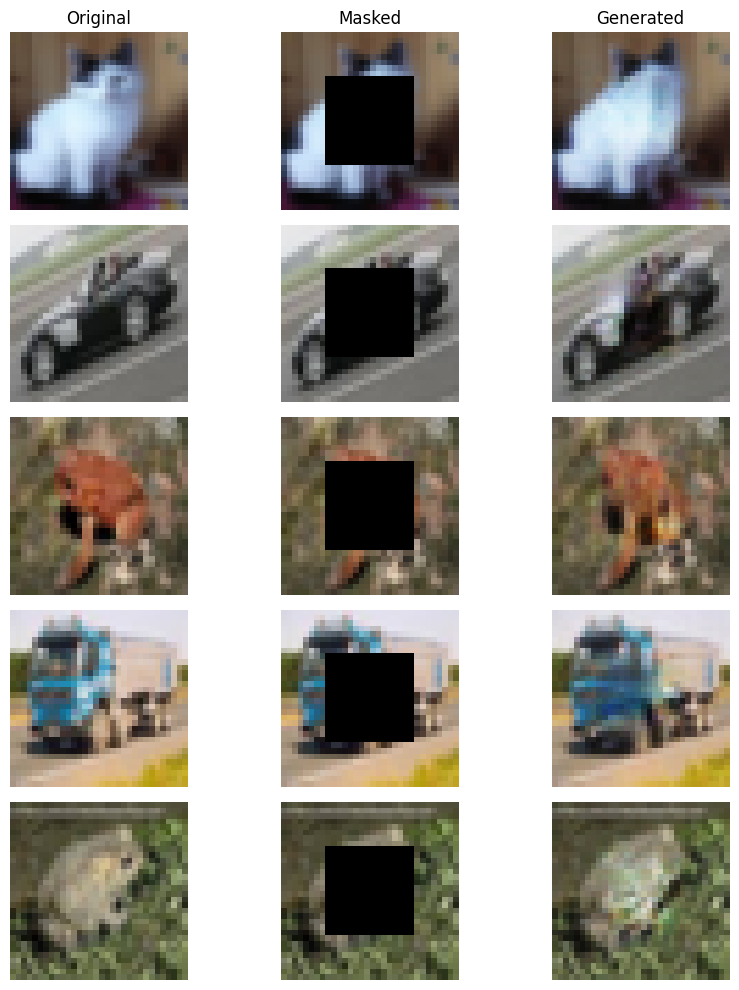

Epoch 61/70: 100%|██████████| 782/782 [00:33<00:00, 23.63it/s]


[Epoch 61/70]  Generator Loss: 0.0461  Discriminator Loss: 0.2875


Epoch 62/70: 100%|██████████| 782/782 [00:33<00:00, 23.50it/s]


[Epoch 62/70]  Generator Loss: 0.0460  Discriminator Loss: 0.2621


Epoch 63/70: 100%|██████████| 782/782 [00:33<00:00, 23.51it/s]


...

[Epoch 68/70]  Generator Loss: 0.0449  Discriminator Loss: 0.2762


Epoch 69/70: 100%|██████████| 782/782 [00:33<00:00, 23.22it/s]


[Epoch 69/70]  Generator Loss: 0.0449  Discriminator Loss: 0.2657


Epoch 70/70: 100%|██████████| 782/782 [00:33<00:00, 23.39it/s]


[Epoch 70/70]  Generator Loss: 0.0446  Discriminator Loss: 0.2744
=> Saved checkpoint at epoch 70


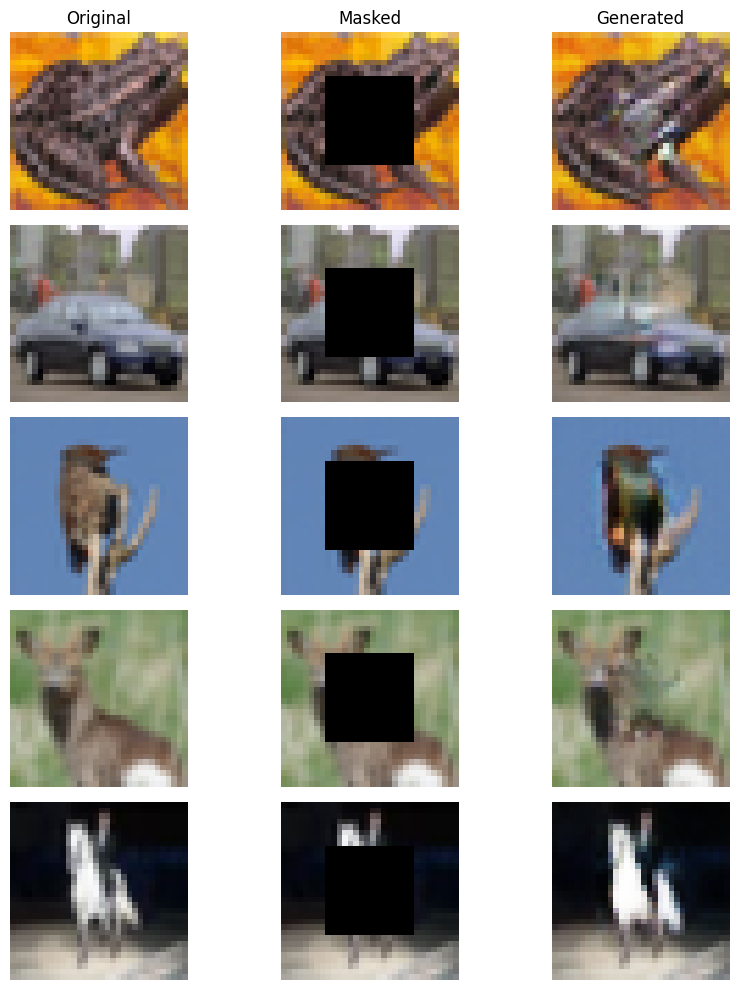

In [12]:
current_epoch = 0
# current_epoch = restore_model(generator, discriminator, g_optimizer, d_optimizer, "checkpoint.pth")

for ep in range(current_epoch, num_epochs):
    total_g_loss = 0.0
    total_d_loss = 0.0

    for batch_imgs, _ in tqdm(train_loader, desc=f"Epoch {ep + 1}/{num_epochs}"):
        batch_imgs = batch_imgs.to(device)
        masked_batch = apply_mask(batch_imgs, mask_size).to(device)

        real_labels = torch.ones(batch_imgs.size(0), 1, 1, 1, device=device)
        fake_labels = torch.zeros(batch_imgs.size(0), 1, 1, 1, device=device)

        discriminator.zero_grad()

        pred_real = discriminator(batch_imgs)
        loss_real = adversarial_loss(pred_real, real_labels)

        gen_output = generator(masked_batch)
        pred_fake = discriminator(gen_output.detach())
        loss_fake = adversarial_loss(pred_fake, fake_labels)

        loss_d = (loss_real + loss_fake) * 0.5
        loss_d.backward()
        d_optimizer.step()

        generator.zero_grad()

        pred_for_gen = discriminator(gen_output)
        adv_component = adversarial_loss(pred_for_gen, real_labels)
        recon_component = reconstruction_loss(gen_output, batch_imgs)

        loss_g = 0.001 * adv_component + recon_component
        loss_g.backward()
        g_optimizer.step()

        total_g_loss += loss_g.item()
        total_d_loss += loss_d.item()

    avg_g_loss = total_g_loss / len(train_loader)
    avg_d_loss = total_d_loss / len(train_loader)
    print(f"[Epoch {ep + 1}/{num_epochs}]  Generator Loss: {avg_g_loss:.4f}  Discriminator Loss: {avg_d_loss:.4f}")

    if (ep + 1) % 5 == 0:
        store_model(generator, discriminator, g_optimizer, d_optimizer, ep + 1, "checkpoint.pth")

    if (ep + 1) % 10 == 0:
        generator.eval()
        with torch.no_grad():
            preview_input = masked_batch[:5]
            preview_output = generator(preview_input)

        generator.train()

        fig, axes = plt.subplots(5, 3, figsize=(9, 10))

        column_titles = ["Original", "Masked", "Generated"]
        for col, title in enumerate(column_titles):
            axes[0, col].set_title(title, fontsize=12)

        for idx in range(5):
            axes[idx, 0].imshow(((batch_imgs[idx].cpu().permute(1, 2, 0) + 1) / 2))
            axes[idx, 0].axis("off")

            axes[idx, 1].imshow(((preview_input[idx].cpu().permute(1, 2, 0) + 1) / 2))
            axes[idx, 1].axis("off")

            axes[idx, 2].imshow(((preview_output[idx].cpu().permute(1, 2, 0) + 1) / 2))
            axes[idx, 2].axis("off")

        plt.tight_layout()
        plt.show()


In [13]:
evaluate_inpainting(generator, train_loader, mask_size=16, device=device)

Average PSNR: 26.78
Average SSIM: 0.90


(np.float64(26.778014613649134), np.float32(0.89662087))

In [14]:
torch.save(generator.state_dict(), "generator.pth")
print("Generator saved.")
torch.save(discriminator.state_dict(), "discriminator_final.pth")
print("Discriminator saved.")

Generator saved.
Discriminator saved.
